# A simple CNN for Digit Recogntion using the MINST Dataset

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Any results you write to the current directory are saved as output.

In [2]:
from keras.datasets import mnist
from keras.utils import to_categorical
import matplotlib.pyplot as plt
from keras import layers
from keras import models

Using TensorFlow backend.


In [3]:
# Load the training and testing set data + labels
(trainData, trainLabels), (testData, testLabels) = mnist.load_data()

11493376/11490434 [==============================] - 0s 0us/step


In [4]:
print("The shape of the training set is: ", trainData.shape)
print("The shape of the test set is: ",testData.shape)
print("The shape of the training labels is: ",trainLabels.shape)
print("The shape of the test labels is: ",testLabels.shape)

The shape of the training set is:  (60000, 28, 28)
The shape of the test set is:  (10000, 28, 28)
The shape of the training labels is:  (60000,)
The shape of the test labels is:  (10000,)


Plot some examples of the data

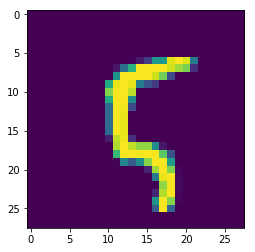

In [5]:
a = trainData[100,:]
g = plt.imshow(a)

In [6]:
# Reshape the data as input to the NN
trainImgs = trainData.reshape((60000,28,28,1))
testImgs = testData.reshape((10000,28,28,1))

In [7]:
# Convert images to float and normalize
trainImgs = trainImgs.astype('float32')/255
testImgs = testImgs.astype('float32')/255

In [8]:
# Change representation from 5 -> 0,0,0,0,0,1,0,0,0,0
trainLabels = to_categorical(trainLabels)
testLabels = to_categorical(testLabels)


**Build the model**

In [9]:
# Note on the filter parameter in Conv2D
# A traditional CNN implementation

model = models.Sequential()
model.add(layers.Conv2D(32,(3,3),activation='relu', input_shape = (28,28,1)))
model.add(layers.MaxPool2D((2,2)))
model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPool2D((2,2)))
model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64,activation='relu'))
model.add(layers.Dense(10,activation='softmax'))

In [10]:
# Let's see how the model looks like
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_1 (Conv2D)            (None, 26, 26, 32)        320       
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 13, 13, 32)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 11, 11, 64)        18496     
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 5, 5, 64)          0         
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 3, 3, 64)          36928     
_________________________________________________________________
flatten_1 (Flatten)          (None, 576)               0         
_________________________________________________________________
dense_1 (Dense)              (None, 64)               

In [11]:
# Compile and train the model

# RMSprop optimizer is similar to the gradient descent algorithm with momentum.

model.compile(optimizer='rmsprop',loss = 'categorical_crossentropy',metrics=['accuracy'])

## Train the model 

In [12]:
model.fit(trainImgs, trainLabels, epochs=5, batch_size=64)

Epoch 1/5
60000/60000 [==============================] - 7s 124us/step - loss: 0.1747 - accuracy: 0.9456
Epoch 2/5
60000/60000 [==============================] - 4s 61us/step - loss: 0.0476 - accuracy: 0.9852
Epoch 3/5
60000/60000 [==============================] - 4s 60us/step - loss: 0.0332 - accuracy: 0.9897
Epoch 4/5
60000/60000 [==============================] - 4s 61us/step - loss: 0.0251 - accuracy: 0.9925
Epoch 5/5
60000/60000 [==============================] - 4s 63us/step - loss: 0.0204 - accuracy: 0.9939


### Evaluate the model on the test set

In [13]:
testLoss, testAccuracy = model.evaluate(testImgs,testLabels)

10000/10000 [==============================] - 1s 63us/step


In [14]:
print("The loss of the trained model is: ",testLoss)
print("The accuracy of the trained model is: ",testAccuracy)


The loss of the trained model is:  0.027003803695891112
The accuracy of the trained model is:  0.9912999868392944
